# Plant Disease Detection using Deep Learning

## Objective
To develop a deep learning model capable of accurately identifying and classifying plant leaf diseases from images. Early detection of diseases can help farmers take timely preventive measures, thereby improving crop productivity.

## Aim
To build a transfer learning-based image classification system that can distinguish between healthy and diseased plant leaves using the PlantVillage dataset. A pre-trained EfficientNetB0 model is fine-tuned on the dataset to leverage features already learned from ImageNet, enabling high accuracy even with limited compute.

## Tech Stack
### Programming Language
- Python

### Libraries
- NumPy
- Pandas
- Matplotlib
- OpenCV
- Scikit-Learn
- TensorFlow / Keras

### Deep Learning Architecture
- Convolutional Neural Networks (CNN)

### Development Environment
- Jupyter Notebook
- Anaconda

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

## 1. Assessing the number of classes in the PlantVillage dataset

In [2]:
dataset_path="PlantVillage"
classes=os.listdir(dataset_path)

print("No. of classes: ",len(classes))
print(classes)

No. of classes:  15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


## 2. Visualizing Sample Images

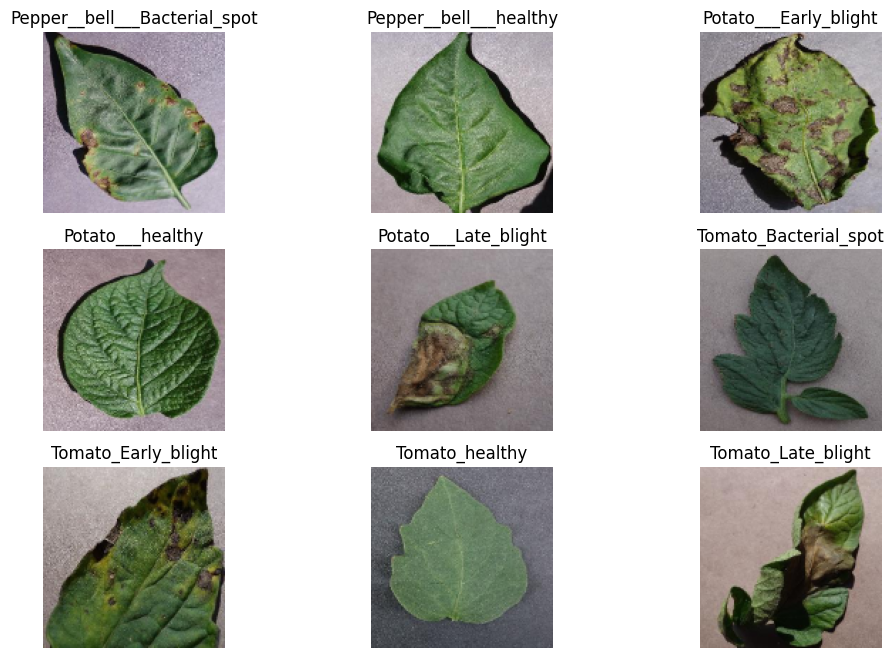

In [3]:
plt.figure(figsize=(12,8))
size=128

for i, cls in enumerate(classes[:9]):
    folder=os.path.join(dataset_path,cls)

    img_name=os.listdir(folder)[0]
    img_path=os.path.join(folder,img_name)

    img=cv2.imread(img_path)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img=cv2.resize(img,(size,size))

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

## 3. Counting number of images per disease class

In [4]:
for cls in classes:
    folder=os.path.join(dataset_path,cls)
    count=len(os.listdir(folder))
    print(f"{cls} : {count}")

Pepper__bell___Bacterial_spot : 995
Pepper__bell___healthy : 1478
Potato___Early_blight : 1000
Potato___healthy : 152
Potato___Late_blight : 1000
Tomato_Bacterial_spot : 2127
Tomato_Early_blight : 1000
Tomato_healthy : 1591
Tomato_Late_blight : 1909
Tomato_Leaf_Mold : 952
Tomato_Septoria_leaf_spot : 1771
Tomato_Spider_mites_Two_spotted_spider_mite : 1676
Tomato__Target_Spot : 1404
Tomato__Tomato_mosaic_virus : 373
Tomato__Tomato_YellowLeaf__Curl_Virus : 3209


## 4. Plot Class Distribution

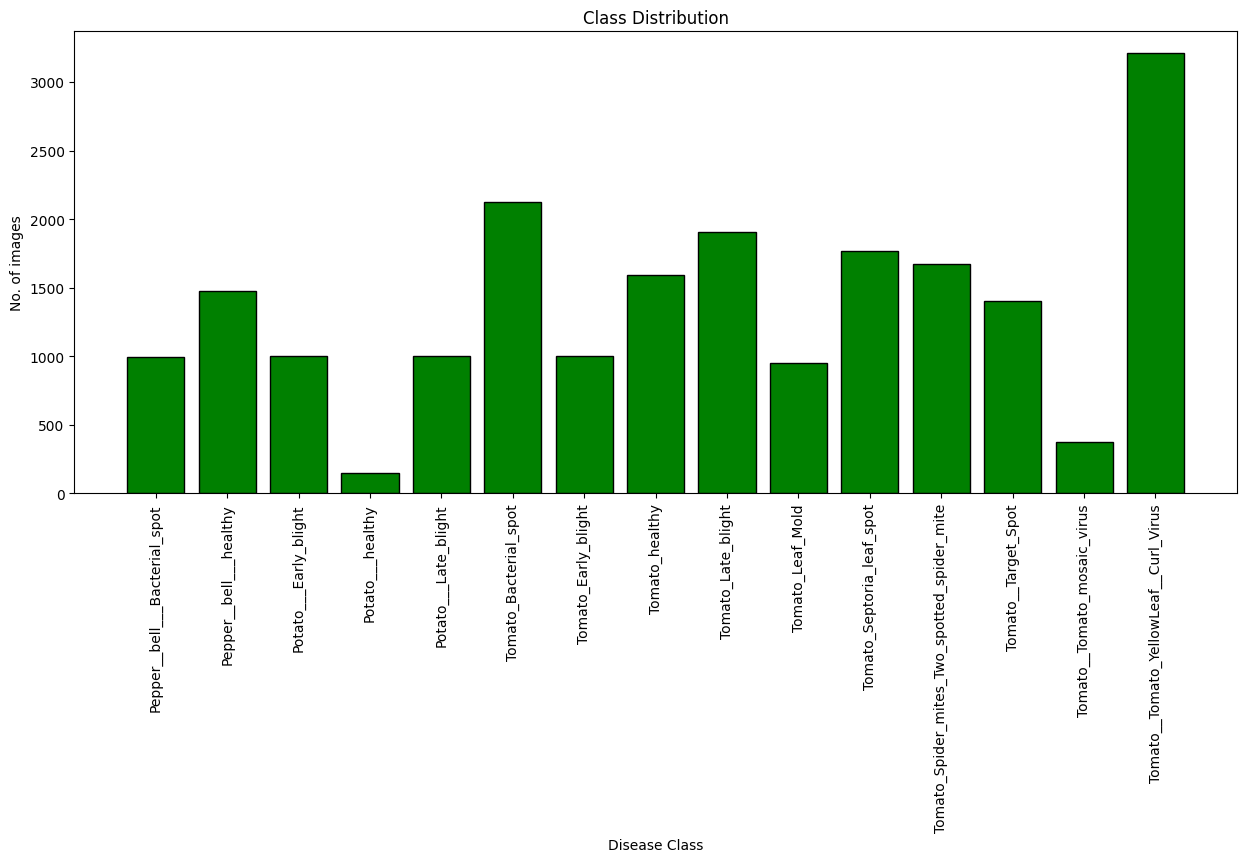

In [5]:
counts=[]

for cls in classes:
    folder=os.path.join(dataset_path,cls)
    counts.append(len(os.listdir(folder)))

plt.figure(figsize=(15,6))
plt.bar(classes,counts,color='green',edgecolor='black')
plt.xticks(rotation=90)
plt.xlabel("Disease Class")
plt.ylabel("No. of images")
plt.title("Class Distribution")
plt.show()

## 5. Inspecting Image Shapes 

In [6]:
for cls in classes[:9]:
    folder=os.path.join(dataset_path,cls)
    img_name=os.listdir(folder)[0]

    img=cv2.imread(os.path.join(folder,img_name))

    print(cls,img.shape)

Pepper__bell___Bacterial_spot (256, 256, 3)
Pepper__bell___healthy (256, 256, 3)
Potato___Early_blight (256, 256, 3)
Potato___healthy (256, 256, 3)
Potato___Late_blight (256, 256, 3)
Tomato_Bacterial_spot (256, 256, 3)
Tomato_Early_blight (256, 256, 3)
Tomato_healthy (256, 256, 3)
Tomato_Late_blight (256, 256, 3)


### Summary of Exploratory Data Analysis

The exploratory data analysis phase helped in understanding the composition of the PlantVillage dataset. By visualizing sample images and examining class distributions, important insights about the data were obtained. The dataset contains 15 classes spanning 3 plant types (Pepper, Potato, Tomato), with images of varying sizes that will be resized uniformly during preprocessing. These findings guide the preprocessing steps in the next section.

## 6. Data Preparation

### Loading and Preprocessing Images

Each image is read using OpenCV, converted from BGR to RGB (OpenCV loads in BGR by default), and resized to 64×64 pixels. Only valid image formats (`.jpg`, `.jpeg`, `.png`) are loaded. Corrupted or unreadable files are flagged and skipped.

In [7]:
valid_extensions = ('.jpg', '.jpeg', '.png')

images=[]
labels=[]

for cls in classes:
    folder=os.path.join(dataset_path, cls)

    for img_name in os.listdir(folder):
        if not img_name.lower().endswith(valid_extensions):
            continue
        
        img_path=os.path.join(folder, img_name)

        img=cv2.imread(img_path)
        if img is None:
           print(img_path)
            
        img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img=cv2.resize(img, (64,64))

        images.append(img)
        labels.append(cls)

### Converting to NumPy Arrays

The image list and label list are converted to NumPy arrays. We print their shapes to confirm the total number of images and that each image has shape `(64, 64, 3)`.

In [8]:
images=np.array(images)
labels=np.array(labels)

print(images.shape)
print(labels.shape)

(20636, 64, 64, 3)
(20636,)


### Casting to Float32

Pixel values are converted from `uint8` (0–255) to `float32`. EfficientNetB0 handles its own internal normalization, so we feed raw float values without dividing by 255.

In [9]:
images=images.astype('float32')

print(images.min())
print(images.max())

0.0
255.0


### Label Encoding

Class names (strings) are encoded into integers using LabelEncoder. This is required since the model outputs integer class indices.

In [10]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

y=le.fit_transform(labels)

print(y[:10])

[0 0 0 0 0 0 0 0 0 0]


### Train / Validation / Test Split

The dataset is split into:
- **70% Training** - used to train the model
- **15% Validation** - used to monitor performance during training
- **15% Test** - held out entirely and used only for final evaluation

`stratify=y` ensures each split has a proportional representation of all 15 classes.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp= train_test_split(images, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test= train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Training Dataset shape: ",X_train.shape)
print("Validation Dataset shape: ", X_val.shape)
print("Test Dataset shape: ",X_test.shape)

Training Dataset shape:  (14445, 64, 64, 3)
Validation Dataset shape:  (3095, 64, 64, 3)
Test Dataset shape:  (3096, 64, 64, 3)


## 7. Transfer Learning Model - EfficientNetB0

**Why Transfer Learning?**
- EfficientNetB0 has already learned general visual features like edges, textures, and shapes from ImageNet.
- By reusing these features, we need far less data and compute compared to training from scratch.
- We set `include_top=False` to remove the original classification head and replace it with our own for 15 classes.
- `base_model.trainable = False` freezes all layers initially so only our custom head is trained first.

In [12]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model=EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(64,64,3)
)

base_model.trainable=False

## 8. Model Architecture, Training and Fine-Tuning

### Phase 1 - Training with Frozen Base
The EfficientNetB0 base is frozen and only the custom classification head is trained. Data augmentation is applied within the model graph to artificially increase training diversity.

### Phase 2 - Fine-Tuning
After the head converges, the last 20 layers of the base model are unfrozen and trained with a very low learning rate (`1e-5`). This allows the model to adapt deeper features specifically to plant disease patterns.

A small augmentation pipeline is defined using Keras layers. It randomly flips, rotates, zooms, and adjusts contrast of images during training. This is applied inside the model graph so augmentation only happens during training, not inference.

In [41]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast

data_augmentation=Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.1),
    RandomZoom(0.1),
    RandomContrast(0.1)
])

The full model is assembled using the Functional API:
1. Input layer -> Augmentation -> EfficientNetB0 base (`training=False` keeps BatchNorm layers frozen)
2. GlobalAveragePooling2D - reduces spatial dimensions to a single vector
3. Dropout(0.3) - regularization to reduce overfitting
4. Dense(15, softmax) - output layer for 15 classes

In [14]:
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense

inputs=Input(shape=(64,64,3))

x=data_augmentation(inputs)

x=base_model(x, training=False)

x=GlobalAveragePooling2D()(x)
x=Dropout(0.3)(x)
outputs=Dense(len(classes),activation='softmax')(x)

model=Model(inputs, outputs)

The model is compiled with:
- **Adam optimizer** - adaptive learning rate, good default choice
- **Sparse Categorical Crossentropy** - used when labels are integers (not one-hot encoded)
- **Accuracy** - metric to monitor during training

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   ## Compiling the model
    metrics=['accuracy']
)

In [16]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint=ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [17]:
history=model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val,y_val),
    callbacks=[checkpoint]
)

Epoch 1/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.4106 - loss: 1.8492  
Epoch 1: val_accuracy improved from None to 0.66785, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 119s 194ms/step - accuracy: 0.5328 - loss: 1.4802 - val_accuracy: 0.6679 - val_loss: 1.0848
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.6409 - loss: 1.1020  
Epoch 2: val_accuracy improved from 0.66785 to 0.70210, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 95s 210ms/step - accuracy: 0.6521 - loss: 1.0589 - val_accuracy: 0.7021 - val_loss: 0.9419
Epoch 3/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.6776 - loss: 0.9784  
Epoch 3: val_accuracy improved from 0.70210 to 0.72439, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 96s 212ms/step - accuracy: 0.6829 - loss

In [18]:
base_model.trainable=True

for layer in base_model.layers[:-20]:
    layer.trainable=False

In [19]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
fine_tune_history=model.fit(
    X_train,
    y_train, 
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint]
)

Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.3695 - loss: 2.8653  
Epoch 1: val_accuracy did not improve from 0.78514
452/452 ━━━━━━━━━━━━━━━━━━━━ 166s 302ms/step - accuracy: 0.4008 - loss: 2.6295 - val_accuracy: 0.5544 - val_loss: 1.7504
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.4788 - loss: 2.1630  
Epoch 2: val_accuracy did not improve from 0.78514
452/452 ━━━━━━━━━━━━━━━━━━━━ 101s 223ms/step - accuracy: 0.4867 - loss: 2.0847 - val_accuracy: 0.6036 - val_loss: 1.5252
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.5302 - loss: 1.8124  
Epoch 3: val_accuracy did not improve from 0.78514
452/452 ━━━━━━━━━━━━━━━━━━━━ 131s 198ms/step - accuracy: 0.5387 - loss: 1.7726 - val_accuracy: 0.6420 - val_loss: 1.3461
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.5611 - loss: 1.6828  
Epoch 4: val_accuracy did not improve from 0.78514
452/452 ━━━━━━━━━━━━━━━━━━━━ 122s 271ms/step - accuracy: 0.5727 - loss: 1

In [37]:
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

In [27]:
from tensorflow.keras.models import load_model

best_model=load_model('best_model.keras')

In [28]:
loss, acc = best_model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")  ## Loss estimated from test data
print(f"Test Accuracy: {acc:.4f}")  ## Accuracy of test data

97/97 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy: 0.7904 - loss: 0.6378
Test Loss: 0.6378
Test Accuracy: 0.7904


In [29]:
y_pred_prob=best_model.predict(X_test)
print("Predicted Data Shape:",y_pred_prob.shape)

y_pred=np.argmax(y_pred_prob, axis=1)

97/97 ━━━━━━━━━━━━━━━━━━━━ 21s 180ms/step
Predicted Data Shape: (3096, 15)


## 9. Classification Report (including metrics such as precision, recall, F1 Score)

In [30]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.81      0.77       149
           1       0.81      0.94      0.87       221
           2       0.84      0.97      0.90       150
           3       0.90      0.80      0.85       150
           4       0.45      1.00      0.62        23
           5       0.87      0.82      0.84       319
           6       0.82      0.42      0.56       150
           7       0.84      0.77      0.81       287
           8       0.78      0.73      0.75       143
           9       0.66      0.75      0.70       266
          10       0.72      0.84      0.78       252
          11       0.62      0.50      0.55       210
          12       0.95      0.90      0.92       481
          13       0.91      0.38      0.53        56
          14       0.71      0.87      0.78       239

    accuracy                           0.79      3096
   macro avg       0.77      0.77      0.75      3096
weighted avg       0.80   

## 10. Confusion Matrix Display

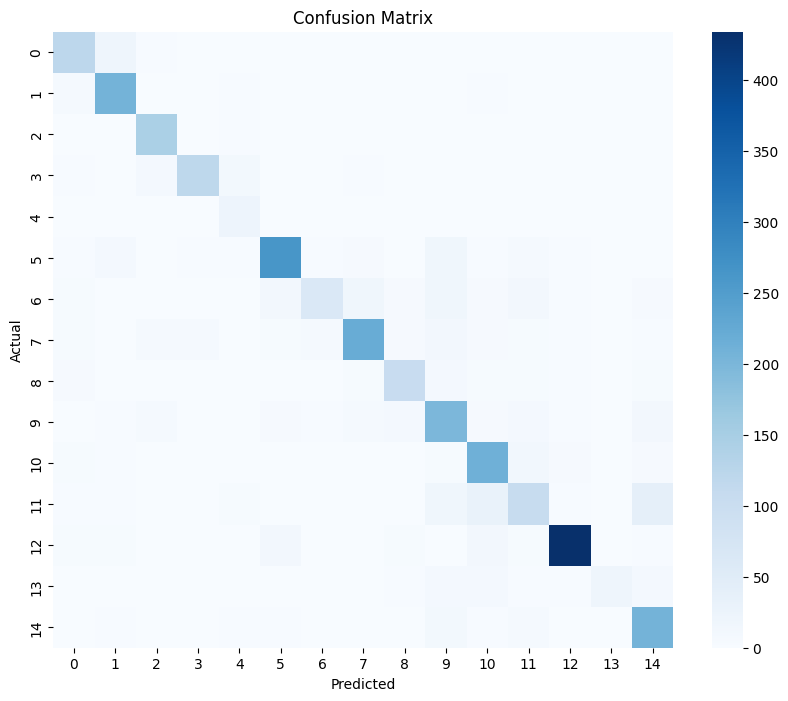

In [31]:
cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [36]:
class_names=le.classes_

row6=cm[6]
print('Tomato Early Blight (actual) predicted as:')
for idx, count in enumerate(row6):
    if count>0:
        print(f'{class_names[idx]}: {count}')
print()

row13=cm[13]
print('Tomato Mosaic Virus (actual) predicted as:')
for idx, count in enumerate(row13):
    if count>0:
        print(f'{class_names[idx]}: {count}')
print()

row11=cm[11]
print('Tomato Spider Mites (actual) predicted as:')
for idx, count in enumerate(row11):
    if count>0:
        print(f'{class_names[idx]}: {count}')

Tomato Early Blight (actual) predicted as:
Pepper__bell___Bacterial_spot: 5
Pepper__bell___healthy: 1
Potato___Late_blight: 1
Tomato_Bacterial_spot: 12
Tomato_Early_blight: 63
Tomato_Late_blight: 18
Tomato_Leaf_Mold: 6
Tomato_Septoria_leaf_spot: 17
Tomato_Spider_mites_Two_spotted_spider_mite: 6
Tomato__Target_Spot: 12
Tomato__Tomato_YellowLeaf__Curl_Virus: 3
Tomato_healthy: 6

Tomato Mosaic Virus (actual) predicted as:
Tomato_Leaf_Mold: 2
Tomato_Septoria_leaf_spot: 9
Tomato_Spider_mites_Two_spotted_spider_mite: 9
Tomato__Target_Spot: 3
Tomato__Tomato_YellowLeaf__Curl_Virus: 3
Tomato__Tomato_mosaic_virus: 21
Tomato_healthy: 9

Tomato Spider Mites (actual) predicted as:
Pepper__bell___Bacterial_spot: 3
Pepper__bell___healthy: 3
Potato___Early_blight: 1
Potato___healthy: 5
Tomato_Bacterial_spot: 1
Tomato_Late_blight: 1
Tomato_Septoria_leaf_spot: 17
Tomato_Spider_mites_Two_spotted_spider_mite: 32
Tomato__Target_Spot: 106
Tomato__Tomato_YellowLeaf__Curl_Virus: 2
Tomato_healthy: 39


### Note
**Precision**: Proportion of correct images among predicted images  
**Recall**: Proportion of actual images correctly identified  
**F1 Score**: Harmonic mean of precision and recall  

## 11. Accuracy Curve Plotting

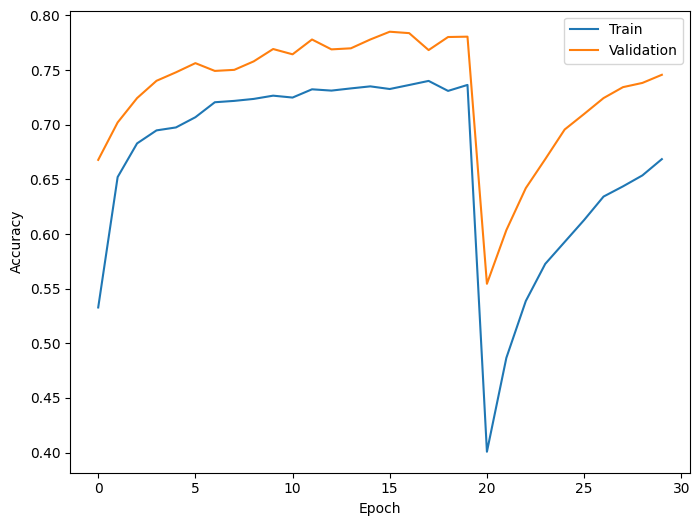

In [38]:
plt.figure(figsize=(8,6))
plt.plot(acc)
plt.plot(val_acc)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

## 12. Loss Curve Plotting

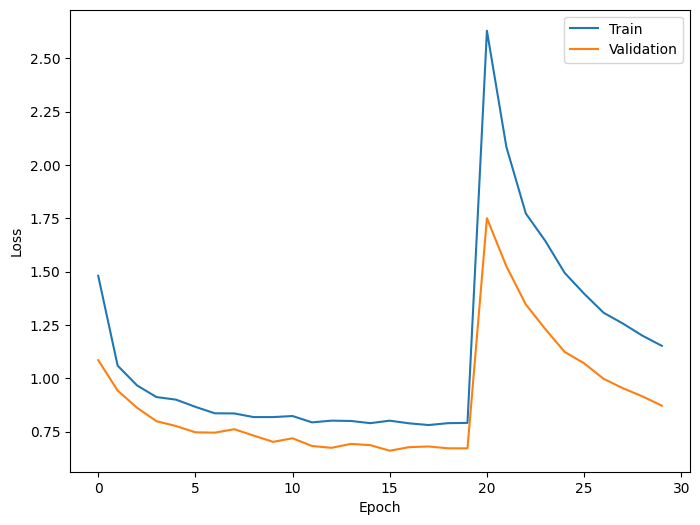

In [39]:
plt.figure(figsize=(8,6))
plt.plot(loss)
plt.plot(val_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()